In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,55.250871,0.230883,False
1,credit_history_woe,29.540155,0.355625,True
2,savings_account_bonds_woe,23.821006,0.230883,False
3,duration_months_woe,21.980634,0.227627,False
4,credit_amount_woe,21.276853,0.146789,False


## load info from previous steps

In [5]:
event = 'bad'

In [6]:
woe_vars = walds['var'].tolist() 
raw_vars = [woe_vars.removesuffix("_woe") for woe_vars in woe_vars]
raw_vars

['checking_account_status',
 'credit_history',
 'savings_account_bonds',
 'duration_months',
 'credit_amount',
 'employment_since',
 'other_installment_plans',
 'housing',
 'purpose',
 'property',
 'installment_rate_percent',
 'telephone',
 'job',
 'existing_credits_at_bank',
 'residence_since',
 'liable_persons']

In [7]:
X = df[raw_vars]
y = df[event]

In [8]:
import numpy as np
import optuna
import toad

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_estimators": 3000,
    
        "max_depth": trial.suggest_int("max_depth", 2, 5),
    
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.25, log=True
        ),
    
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 30.0, log=True
        ),
    
        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),
    
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),
    
        "gamma": trial.suggest_float(
            "gamma", 1e-6, 5.0, log=True
        ),
    
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),
    
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1.0, 100.0, log=True
        ),
    
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 100,
    }


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        # Fit bins only on this fold's training data
        combiner = toad.transform.Combiner()

        combiner.fit(
            X_fold_train,
            y=y_fold_train,
            method="chi",
            min_samples=0.05
        )

        # Transform both sets using training-fold bin rules
        X_fold_train_bins = combiner.transform(X_fold_train)
        X_fold_valid_bins = combiner.transform(X_fold_valid)

        # Fit WoE only on this fold's training bins
        woe = toad.transform.WOETransformer()

        woe.fit(
            X_fold_train_bins,
            y_fold_train
        )

        # Transform validation data using training-fold WoE mappings
        X_fold_train_woe = woe.transform(X_fold_train_bins)
        X_fold_valid_woe = woe.transform(X_fold_valid_bins)


        # add suffix


        X_fold_train_woe = X_fold_train_woe.add_suffix("_woe")
        X_fold_valid_woe = X_fold_valid_woe.add_suffix("_woe")

        model = XGBClassifier(**params)

        model.fit(
            X_fold_train_woe,
            y_fold_train,
            eval_set=[(X_fold_valid_woe, y_fold_valid)],
            verbose=False
        )

        valid_probabilities = model.predict_proba(
            X_fold_valid_woe
        )[:, 1]

        fold_auc = roc_auc_score(
            y_fold_valid,
            valid_probabilities
        )

        fold_scores.append(fold_auc)

        # Optional pruning during the Optuna trial
        trial.report(np.mean(fold_scores), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


In [9]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-11 18:20:15,304] A new study created in memory with name: no-name-7e221b84-b7dd-42cc-8cdf-89e93064b778


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-11 18:20:15,640] Trial 0 finished with value: 0.7814484126984128 and parameters: {'max_depth': 3, 'learning_rate': 0.2133249073808361, 'min_child_weight': 12.057126287443763, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 1.1091814877139725e-05, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 53.99484409787433}. Best is trial 0 with value: 0.7814484126984128.
[I 2026-09-11 18:20:15,931] Trial 1 finished with value: 0.7737103174603175 and parameters: {'max_depth': 4, 'learning_rate': 0.09768839753070749, 'min_child_weight': 1.0725209743171995, 'subsample': 0.9909729556485982, 'colsample_bytree': 0.9497327922401265, 'gamma': 2.6451684446721577e-05, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 2.32706770838378}. Best is trial 0 with value: 0.7814484126984128.
[I 2026-09-11 18:20:16,265] Trial 2 finished with value: 0.7857142857142856 and parameters: {'max_depth': 3, 'learning_rate': 0.05414745020542119, 'min_child_weight': 4.3454541097

In [10]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.7922949735449736
Best parameters:
{'max_depth': 3, 'learning_rate': 0.04840092257036659, 'min_child_weight': 4.882503770895032, 'subsample': 0.7810898971698561, 'colsample_bytree': 0.9786718134004345, 'gamma': 1.1575247941286734e-05, 'reg_alpha': 0.0015833832949644112, 'reg_lambda': 5.666908534159068}


## optimization summary

In [11]:
import matplotlib.pyplot as plt

In [12]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_2408290/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


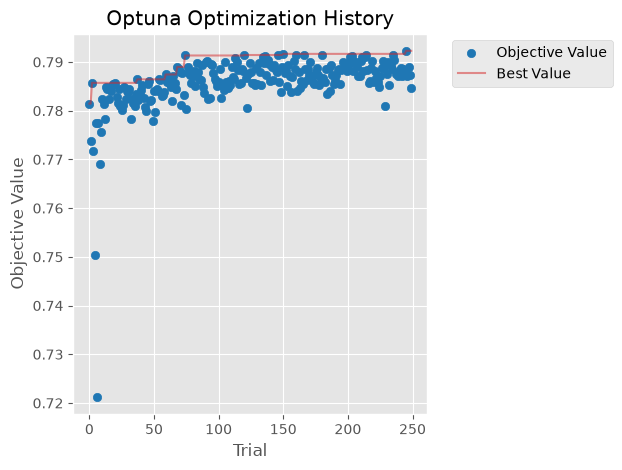

In [13]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408290/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


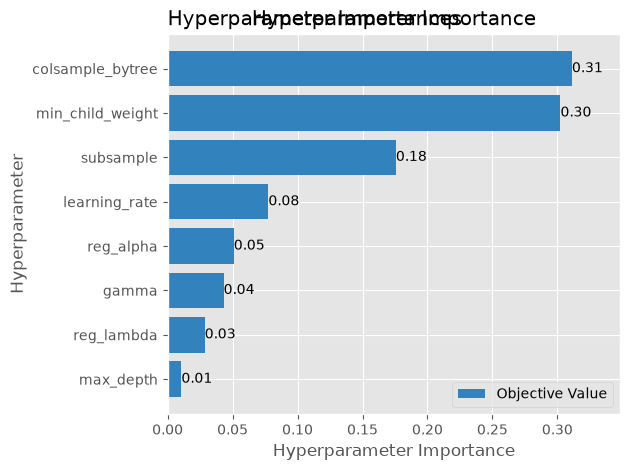

In [14]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408290/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_2408290/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


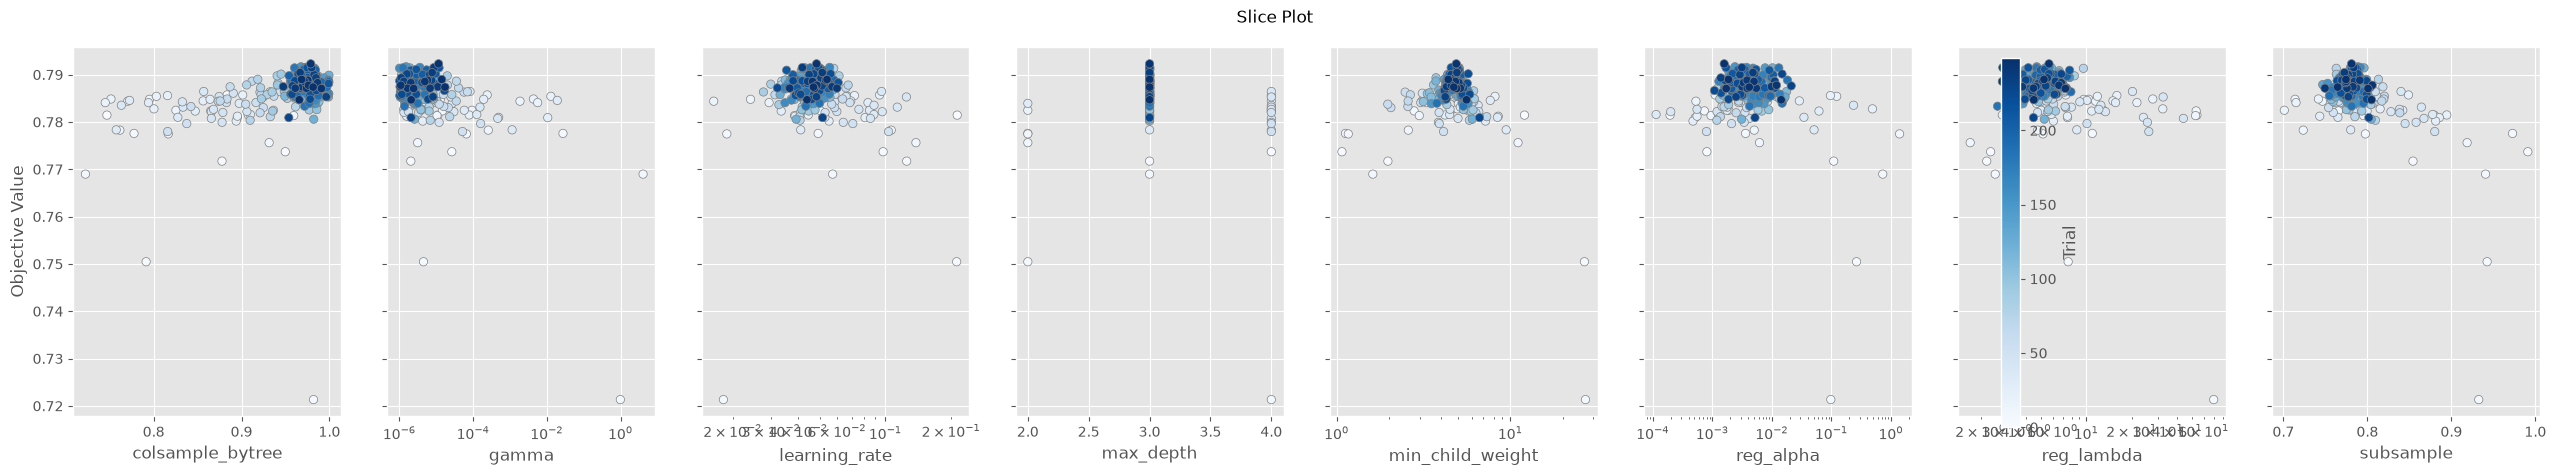

In [15]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408290/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


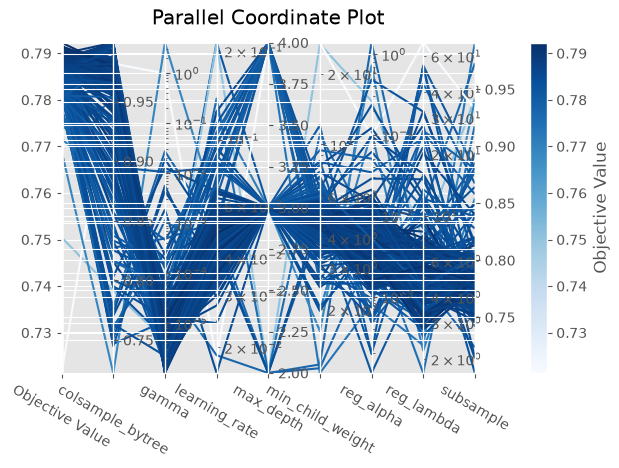

In [16]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408290/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


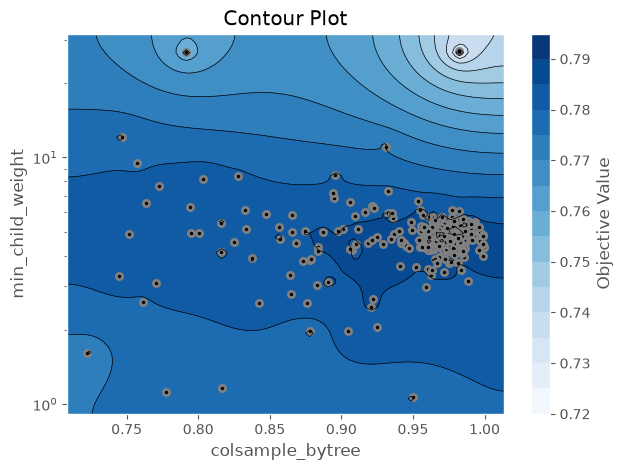

In [17]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [18]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [19]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
245,245,0.792295,2026-09-11 18:21:48.896176,2026-09-11 18:21:49.219791,0 days 00:00:00.323615,0.978672,0.000012,0.048401,3,4.882504,0.001583,5.666909,0.781090,"{""colsample_bytree"": 0.9786718134004345, ""gamm...",COMPLETE
150,150,0.791667,2026-09-11 18:21:13.860170,2026-09-11 18:21:14.187783,0 days 00:00:00.327613,0.967589,0.000002,0.049111,3,4.874863,0.002401,4.701117,0.788686,"{""colsample_bytree"": 0.9675890541148668, ""gamm...",COMPLETE
166,166,0.791534,2026-09-11 18:21:19.459491,2026-09-11 18:21:19.755568,0 days 00:00:00.296077,0.972565,0.000004,0.055563,3,5.031127,0.003755,5.681591,0.791453,"{""colsample_bytree"": 0.9725650801017705, ""gamm...",COMPLETE
235,235,0.791501,2026-09-11 18:21:45.545362,2026-09-11 18:21:45.861910,0 days 00:00:00.316548,0.979771,0.000009,0.041655,3,4.932528,0.003139,2.801311,0.783687,"{""colsample_bytree"": 0.9797708223013837, ""gamm...",COMPLETE
214,214,0.791468,2026-09-11 18:21:38.214726,2026-09-11 18:21:38.561190,0 days 00:00:00.346464,0.974626,0.000012,0.049464,3,4.561474,0.001699,4.132549,0.786195,"{""colsample_bytree"": 0.974626431180606, ""gamma...",COMPLETE
180,180,0.791435,2026-09-11 18:21:24.298860,2026-09-11 18:21:24.586268,0 days 00:00:00.287408,0.960287,0.000001,0.045288,3,4.620143,0.013065,4.678275,0.781409,"{""colsample_bytree"": 0.9602873740066915, ""gamm...",COMPLETE
120,120,0.791435,2026-09-11 18:21:03.480970,2026-09-11 18:21:03.811357,0 days 00:00:00.330387,0.971831,0.000002,0.042890,3,5.075619,0.010241,5.886975,0.795995,"{""colsample_bytree"": 0.9718308658336758, ""gamm...",COMPLETE
146,146,0.791435,2026-09-11 18:21:12.468603,2026-09-11 18:21:12.795441,0 days 00:00:00.326838,0.969032,0.000001,0.050005,3,4.900394,0.007703,5.364926,0.779592,"{""colsample_bytree"": 0.9690319678094069, ""gamm...",COMPLETE
160,160,0.791369,2026-09-11 18:21:17.202436,2026-09-11 18:21:17.516394,0 days 00:00:00.313958,0.982941,0.000001,0.042204,3,4.838634,0.004822,2.833314,0.781179,"{""colsample_bytree"": 0.9829411246542177, ""gamm...",COMPLETE
74,74,0.791336,2026-09-11 18:20:44.864614,2026-09-11 18:20:45.182396,0 days 00:00:00.317782,0.965493,0.000008,0.058010,3,4.981420,0.003111,9.579374,0.762890,"{""colsample_bytree"": 0.9654933158640097, ""gamm...",COMPLETE


# fit best model

In [20]:
# use woe from entire training data
X = df[woe_vars]

In [21]:
# from xgboost import XGBClassifier

best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9786718134004345
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

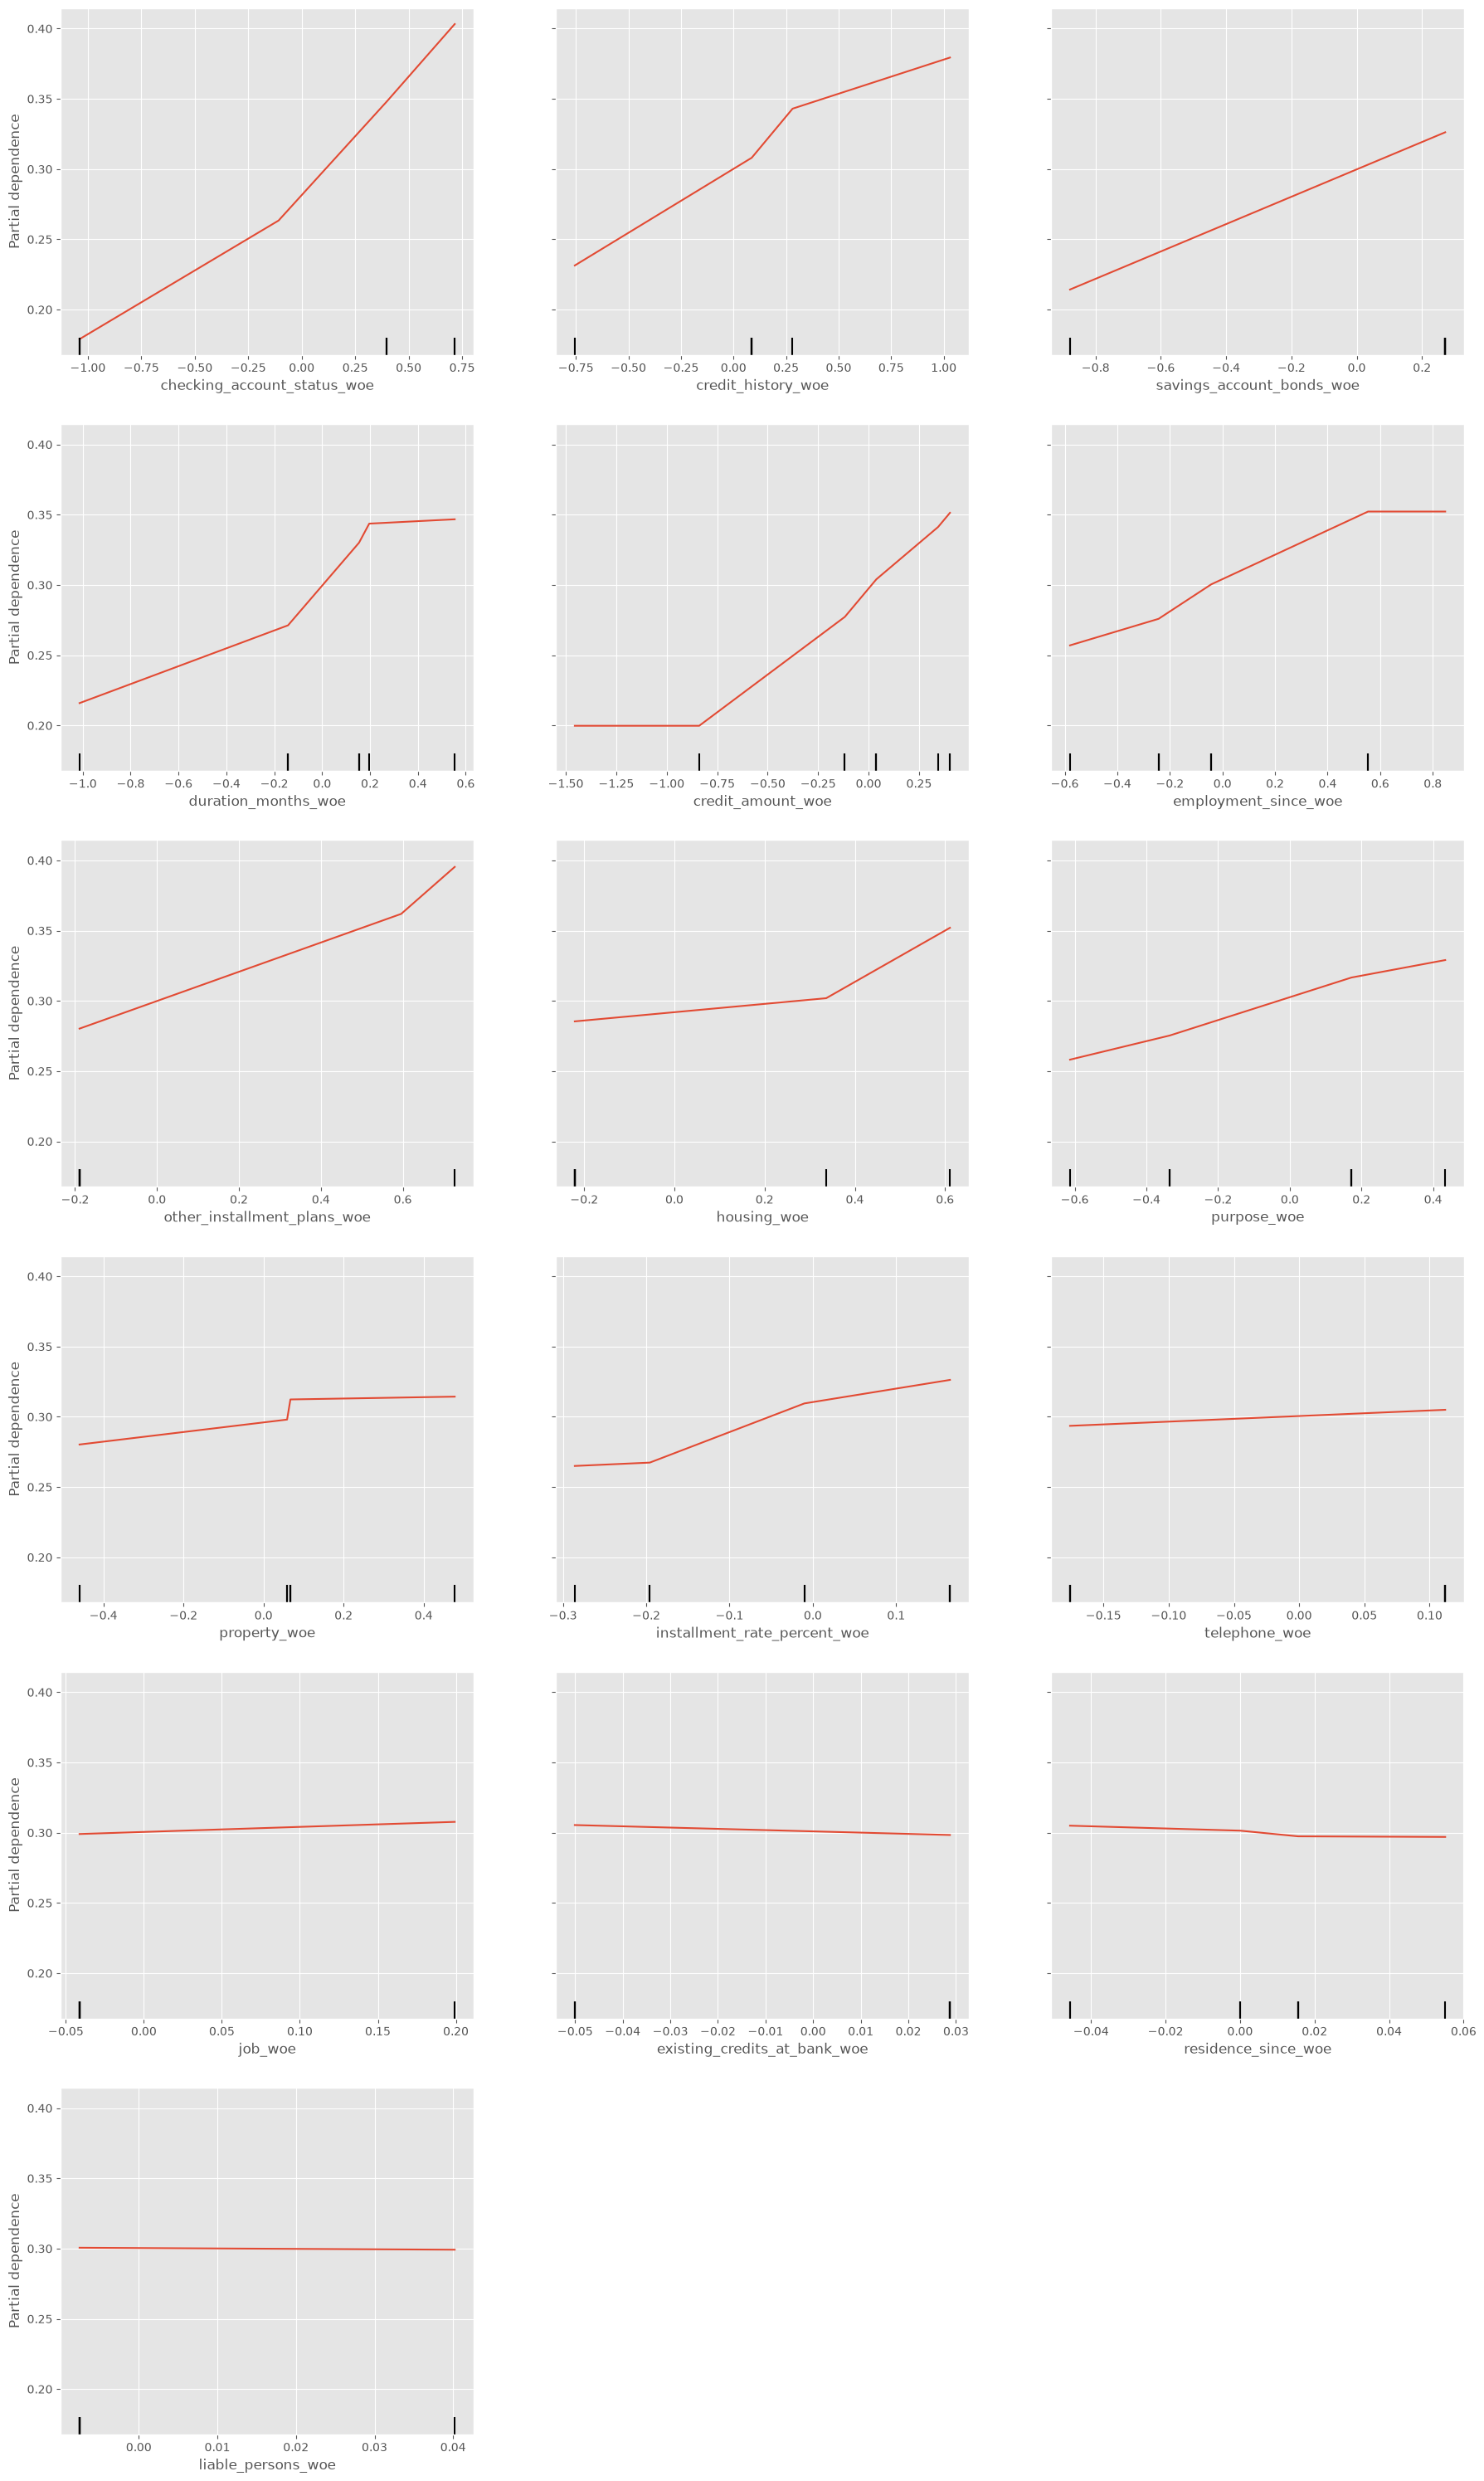

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=features,
    n_cols=3
)

n_rows = (len(features) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [23]:
models['xgb woe'] = final_model

In [24]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)